In [1]:
import pandas as pd
import json

import random
import geopandas as gpd
import numpy as np
import os

enc = 'utf-8'
random.seed(0)
np.random.seed(0)


In [2]:
folder_path = 'shapefiles/EUROPE_NUTS_2021_4326'   

europe_nuts = gpd.read_file(f"{folder_path}/NUTS_RG_01M_2021_4326.shp",  encoding=enc)

In [3]:
with open('country_codes.json') as json_file:
    country_codes = json.load(json_file)

In [4]:
europe_nuts

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,FID,geometry
0,CZ,0,CZ,Česko,Česko,0.0,0,0,CZ,"POLYGON ((14.49122 51.04353, 14.49945 51.04610..."
1,DE,0,DE,Deutschland,Deutschland,0.0,0,0,DE,"MULTIPOLYGON (((10.45444 47.55580, 10.43954 47..."
2,DK,0,DK,Danmark,Danmark,0.0,0,0,DK,"MULTIPOLYGON (((15.19308 55.32014, 15.19056 55..."
3,AL,0,AL,Shqipëria,Shqipëria,0.0,0,0,AL,"MULTIPOLYGON (((19.83100 42.46645, 19.83568 42..."
4,CY,0,CY,Kýpros,Κύπρος,0.0,0,0,CY,"MULTIPOLYGON (((34.60609 35.70767, 34.60060 35..."
...,...,...,...,...,...,...,...,...,...,...
2005,UKM73,3,UK,East Lothian and Midlothian,East Lothian and Midlothian,4.0,1,1,UKM73,"MULTIPOLYGON (((-2.36662 55.94611, -2.36697 55..."
2006,UKM75,3,UK,"Edinburgh, City of","Edinburgh, City of",4.0,1,1,UKM75,"MULTIPOLYGON (((-3.07764 55.94689, -3.08167 55..."
2007,UKM76,3,UK,Falkirk,Falkirk,4.0,1,1,UKM76,"POLYGON ((-3.51572 56.00226, -3.51251 55.99411..."
2008,UKM78,3,UK,West Lothian,West Lothian,4.0,1,1,UKM78,"POLYGON ((-3.42533 55.99403, -3.42699 55.99050..."


In [5]:
selected_row = europe_nuts.loc[europe_nuts['NUTS_ID'] == 'EL52']

In [6]:
selected_row.to_file('Greece/data/EL52.shp', encoding = enc)

In [7]:
europe_nuts['CNTR_NAME'] = europe_nuts['CNTR_CODE'].map(country_codes) 

In [8]:
europe_nuts

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,FID,geometry,CNTR_NAME
0,CZ,0,CZ,Česko,Česko,0.0,0,0,CZ,"POLYGON ((14.49122 51.04353, 14.49945 51.04610...",Czech Republic
1,DE,0,DE,Deutschland,Deutschland,0.0,0,0,DE,"MULTIPOLYGON (((10.45444 47.55580, 10.43954 47...",Germany
2,DK,0,DK,Danmark,Danmark,0.0,0,0,DK,"MULTIPOLYGON (((15.19308 55.32014, 15.19056 55...",Denmark
3,AL,0,AL,Shqipëria,Shqipëria,0.0,0,0,AL,"MULTIPOLYGON (((19.83100 42.46645, 19.83568 42...",Albania
4,CY,0,CY,Kýpros,Κύπρος,0.0,0,0,CY,"MULTIPOLYGON (((34.60609 35.70767, 34.60060 35...",Cyprus
...,...,...,...,...,...,...,...,...,...,...,...
2005,UKM73,3,UK,East Lothian and Midlothian,East Lothian and Midlothian,4.0,1,1,UKM73,"MULTIPOLYGON (((-2.36662 55.94611, -2.36697 55...",United Kingdom
2006,UKM75,3,UK,"Edinburgh, City of","Edinburgh, City of",4.0,1,1,UKM75,"MULTIPOLYGON (((-3.07764 55.94689, -3.08167 55...",United Kingdom
2007,UKM76,3,UK,Falkirk,Falkirk,4.0,1,1,UKM76,"POLYGON ((-3.51572 56.00226, -3.51251 55.99411...",United Kingdom
2008,UKM78,3,UK,West Lothian,West Lothian,4.0,1,1,UKM78,"POLYGON ((-3.42533 55.99403, -3.42699 55.99050...",United Kingdom


In [9]:
europe_nuts['NUTS_ID'].equals(europe_nuts['FID'])

True

In [10]:
europe_nuts.drop(columns=['FID'], inplace = True)

In [11]:
europe_nuts0 = europe_nuts.loc[europe_nuts['LEVL_CODE'] == 0].copy()
europe_nuts1 = europe_nuts.loc[europe_nuts['LEVL_CODE'] == 1].copy()
europe_nuts2 = europe_nuts.loc[europe_nuts['LEVL_CODE'] == 2].copy()
europe_nuts3 = europe_nuts.loc[europe_nuts['LEVL_CODE'] == 3].copy()

In [12]:
europe_nuts0.drop(columns=['LEVL_CODE', 'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE'], inplace = True)
europe_nuts1.drop(columns=['LEVL_CODE', 'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE'], inplace = True)
europe_nuts2.drop(columns=['LEVL_CODE', 'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE'], inplace = True)
europe_nuts3.drop(columns=['LEVL_CODE'], inplace = True)

europe_nuts0.reset_index(drop=True, inplace=True)
europe_nuts1.reset_index(drop=True, inplace=True)
europe_nuts2.reset_index(drop=True, inplace=True)
europe_nuts3.reset_index(drop=True, inplace=True)

In [13]:
print(f'europe_nuts0 CRS: {europe_nuts0.crs}')
print(f'europe_nuts1 CRS: {europe_nuts1.crs}')
print(f'europe_nuts2 CRS: {europe_nuts2.crs}')
print(f'europe_nuts3 CRS: {europe_nuts3.crs}')

europe_nuts0 CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
europe_nuts1 CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
europe_nuts2 CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
europe_nuts3 CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]


In [14]:
europe_nuts0 = europe_nuts0.to_crs(epsg=4326)
europe_nuts1 = europe_nuts1.to_crs(epsg=4326)
europe_nuts2 = europe_nuts2.to_crs(epsg=4326)
europe_nuts3 = europe_nuts3.to_crs(epsg=4326)

In [15]:
print(f'europe_nuts0 CRS: {europe_nuts0.crs}')
print(f'europe_nuts1 CRS: {europe_nuts1.crs}')
print(f'europe_nuts2 CRS: {europe_nuts2.crs}')
print(f'europe_nuts3 CRS: {europe_nuts3.crs}')

europe_nuts0 CRS: EPSG:4326
europe_nuts1 CRS: EPSG:4326
europe_nuts2 CRS: EPSG:4326
europe_nuts3 CRS: EPSG:4326


<Axes: >

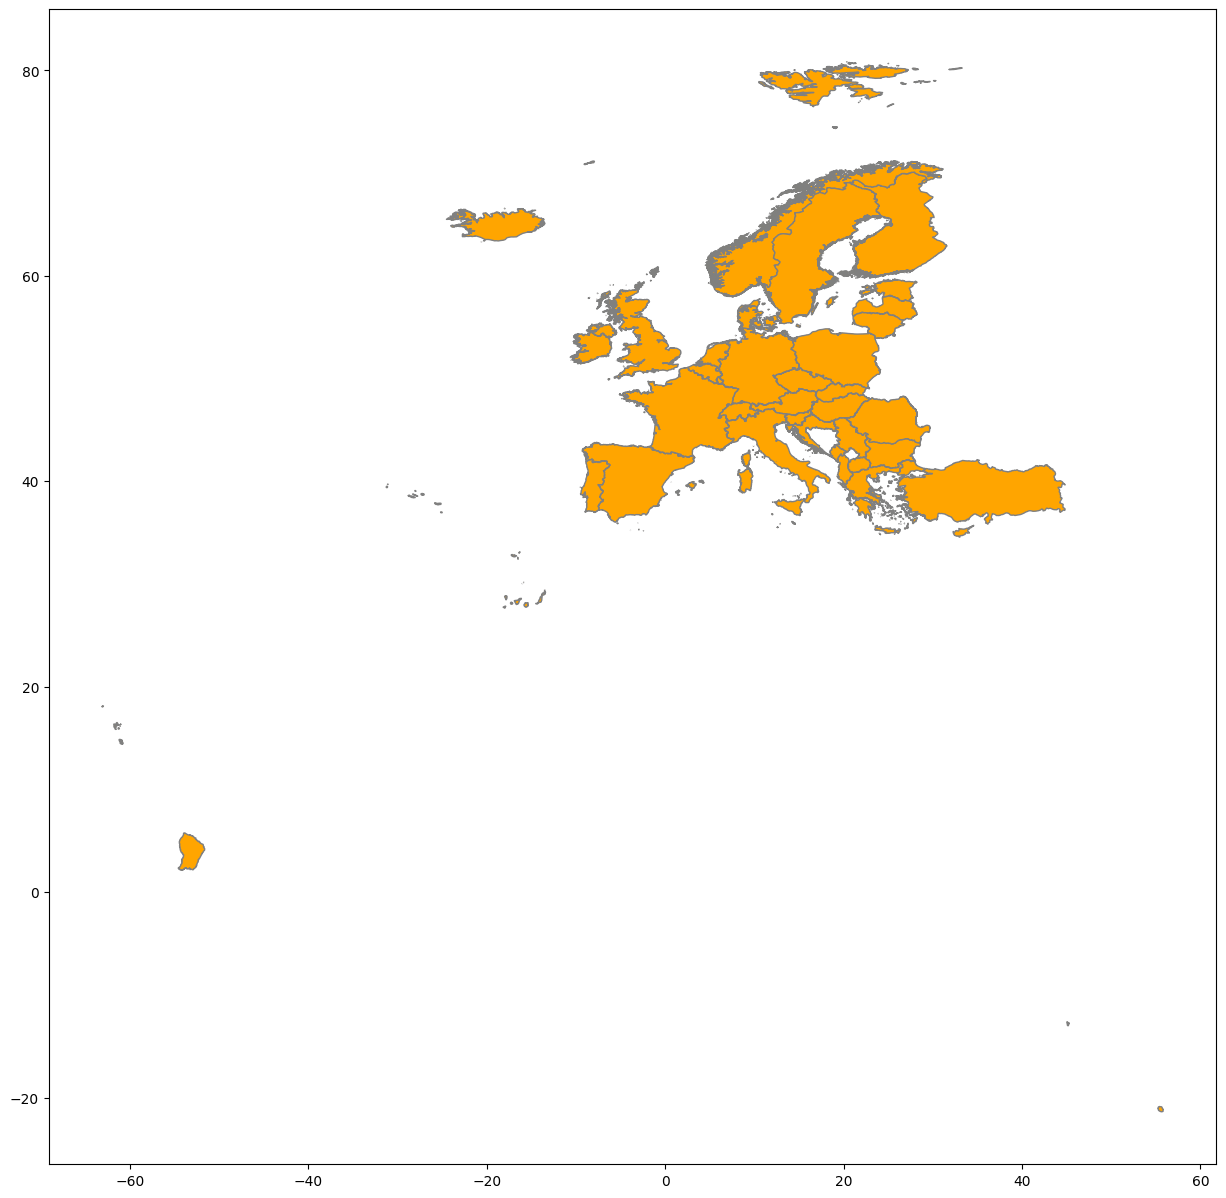

In [16]:
europe_nuts0.plot(facecolor="none", edgecolor='grey', figsize=(20, 15), color='orange')

<Axes: >

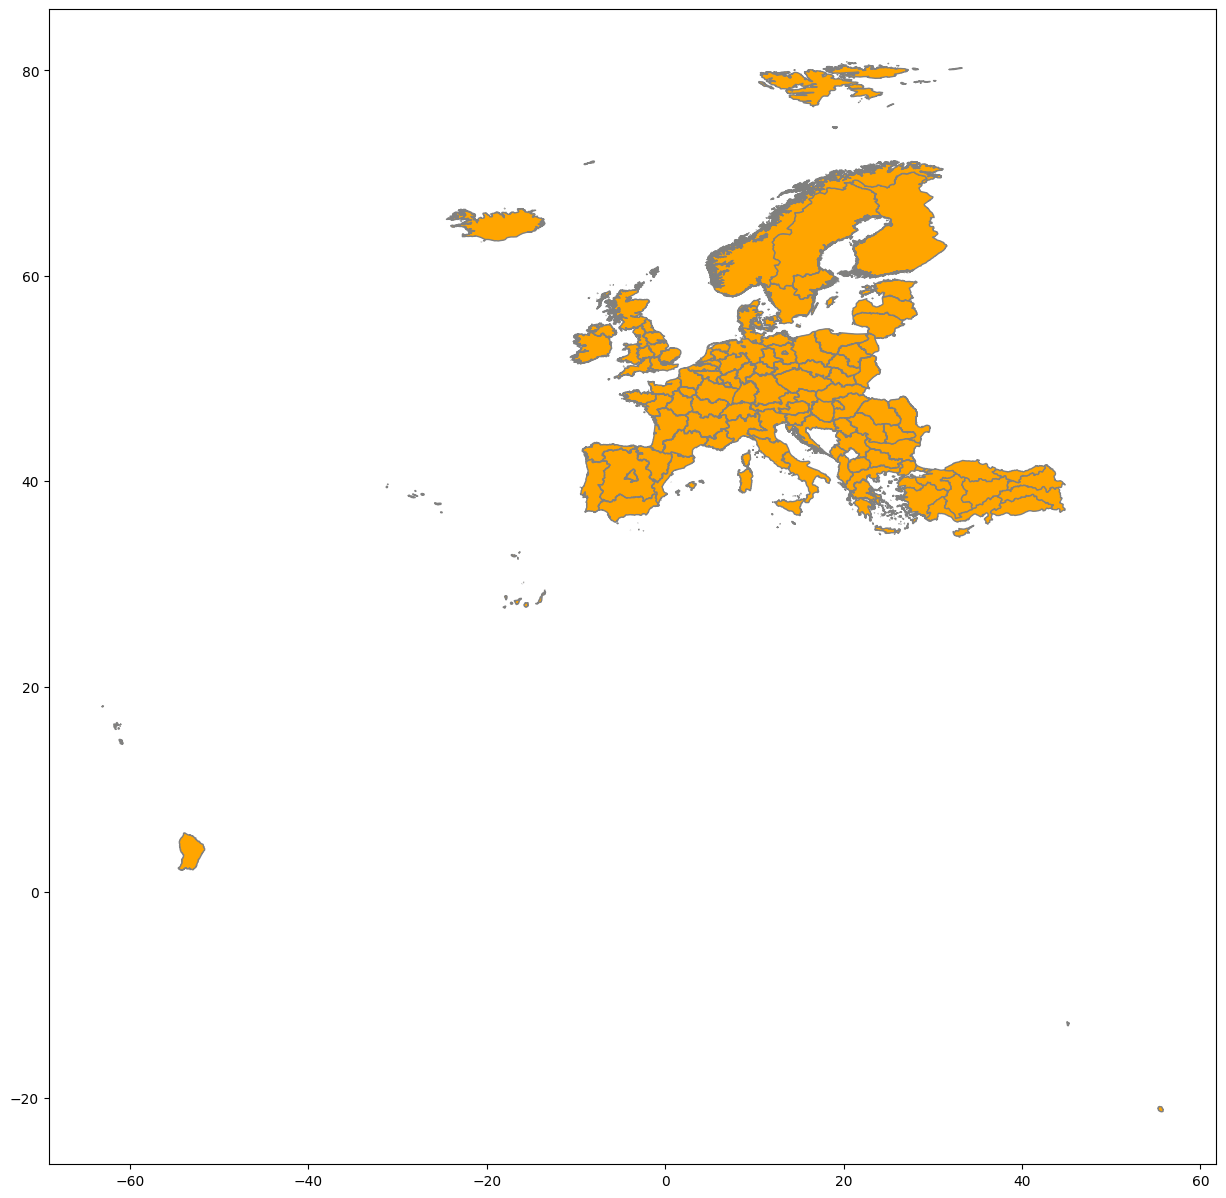

In [17]:
europe_nuts1.plot(facecolor="none", edgecolor='grey', figsize=(20, 15), color='orange')

<Axes: >

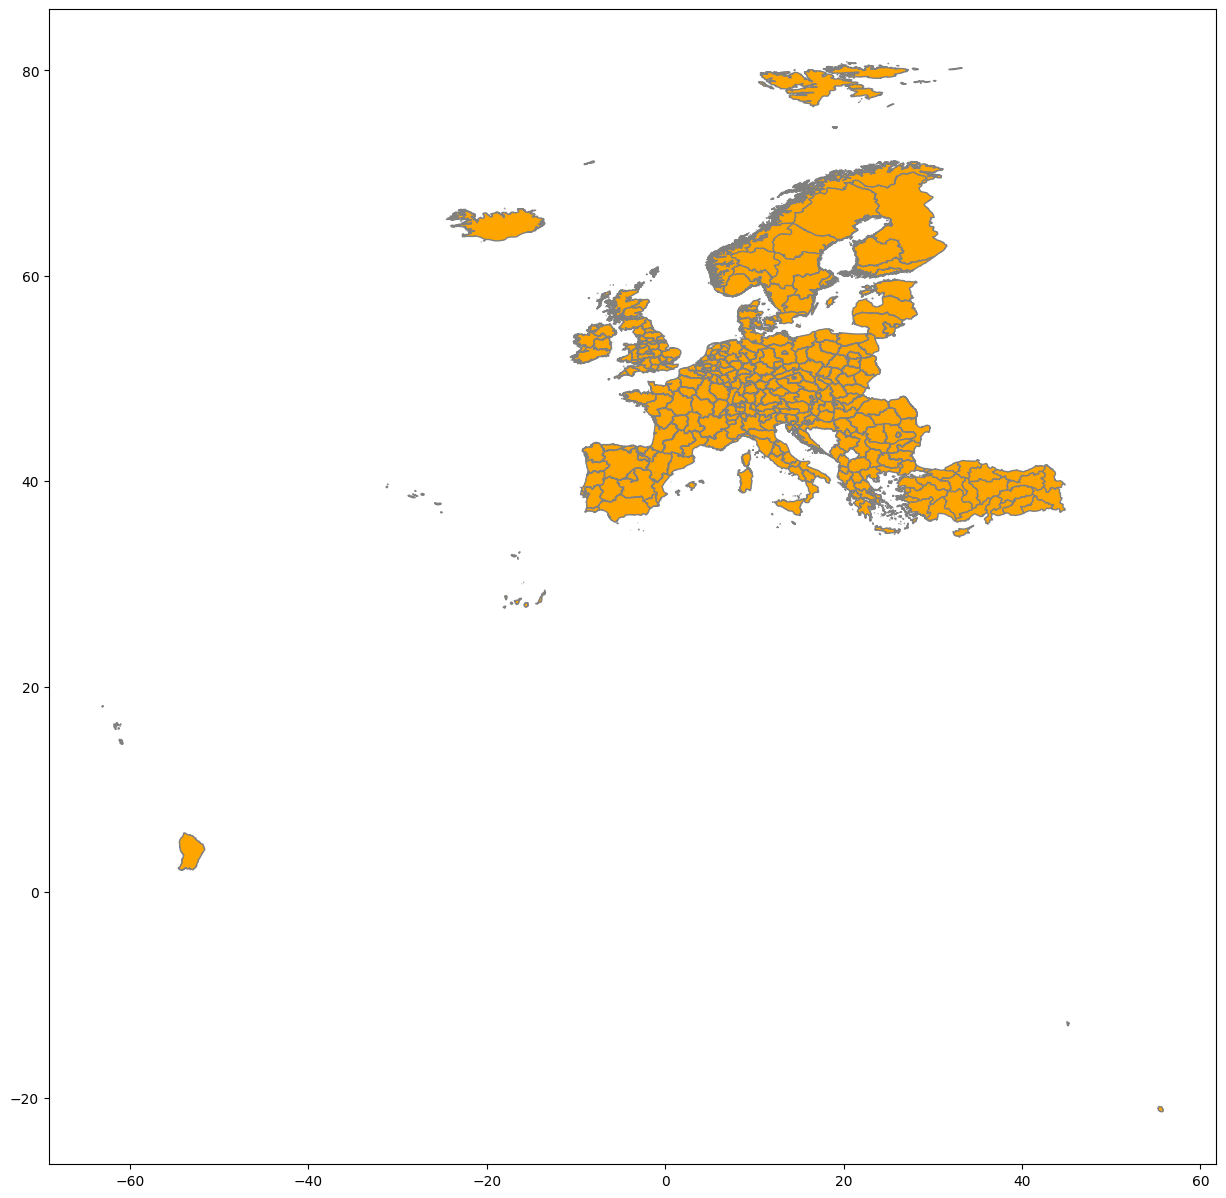

In [18]:
europe_nuts2.plot(facecolor="none", edgecolor='grey', figsize=(20, 15), color='orange')

<Axes: >

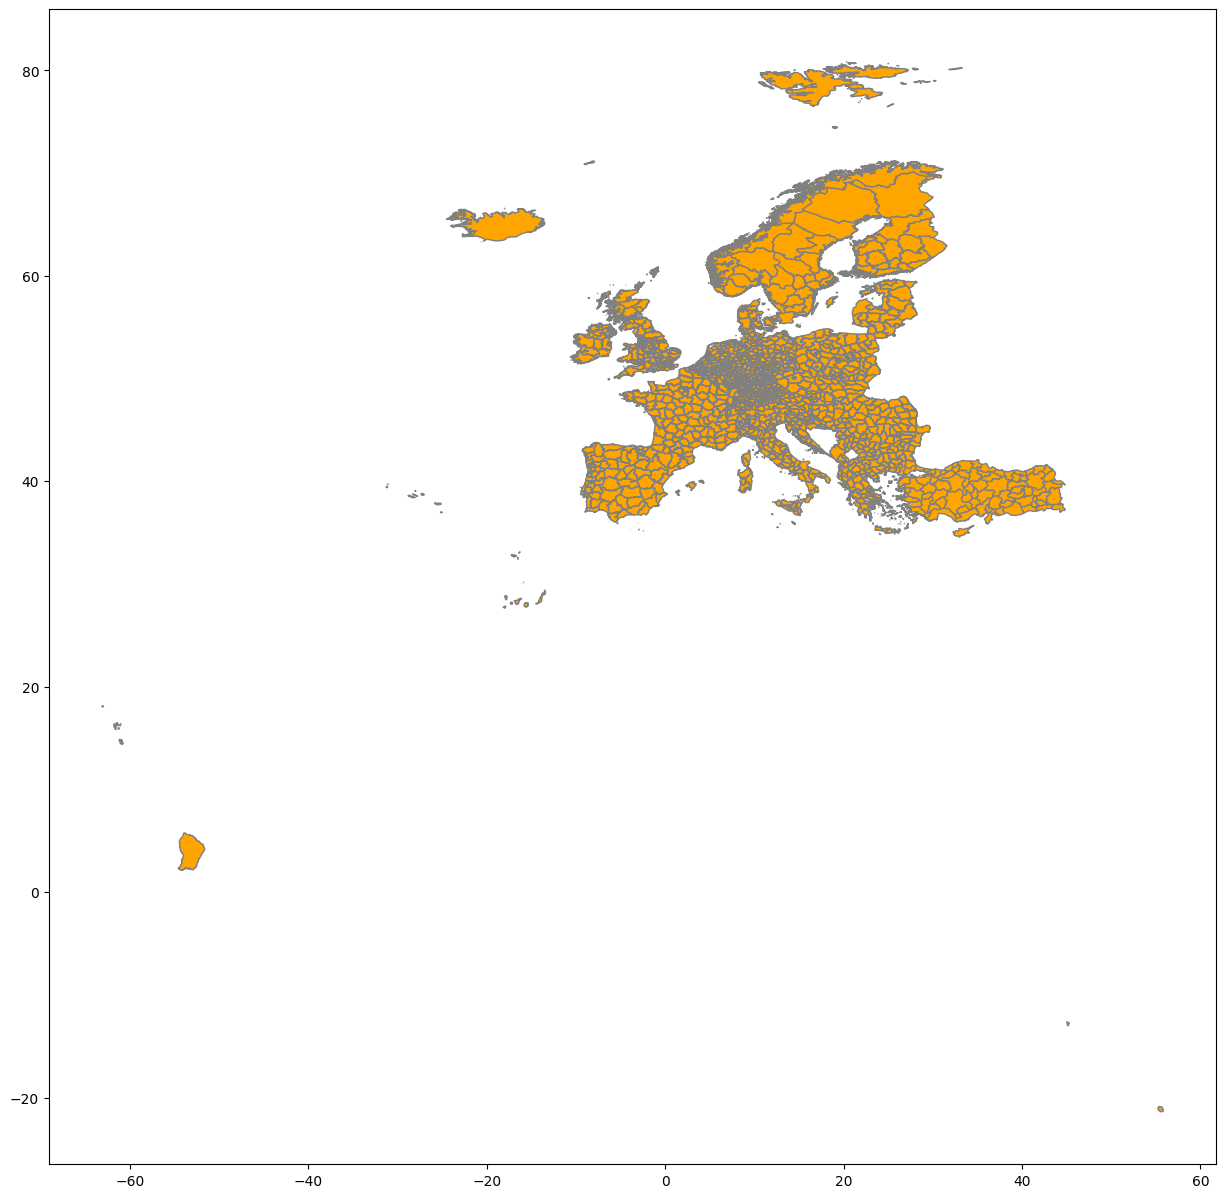

In [19]:
europe_nuts3.plot(facecolor="none", edgecolor='grey', figsize=(20, 15), color='orange')

In [20]:
# europe_nuts0.to_file('EU_NUTS0_4326.shp', encoding = enc)
# europe_nuts1.to_file('EU_NUTS1_4326.shp', encoding = enc)
# europe_nuts2.to_file('EU_NUTS2_4326.shp', encoding = enc)
# europe_nuts3.to_file('EU_NUTS3_4326.shp', encoding = enc)

In [21]:
italy2 = europe_nuts2.loc[europe_nuts2['CNTR_CODE'] == 'IT']

In [22]:
veneto = italy2.loc[italy2['NUTS_ID'] == 'ITH3']

In [23]:
veneto.reset_index(drop= True, inplace=True)

In [24]:
print(f'veneto CRS: {veneto.crs}')

veneto CRS: EPSG:4326


In [26]:
# points_file = pd.read_csv('random_data/italy_stations.csv', encoding='utf-8')

In [23]:
points_file

,x,y
0,12.877089,45.606292
1,12.213579,45.519400
2,11.670841,45.559359
3,11.117869,45.314329
4,12.550696,45.693042
...,...,...
172,12.049587,44.986146
173,12.674271,45.983511
174,12.139038,45.361250
175,11.800410,45.405474


In [28]:
points_gdf = gpd.GeoDataFrame(points_file, geometry=gpd.points_from_xy(points_file.x, points_file.y), crs=4326)

In [29]:
print(f'points_gdf CRS: {points_gdf.crs}')

points_gdf CRS: EPSG:4326


In [30]:
points_gdf

,x,y,geometry
0,12.877089,45.606292,POINT (12.87709 45.60629)
1,12.213579,45.519400,POINT (12.21358 45.51940)
2,11.670841,45.559359,POINT (11.67084 45.55936)
3,11.117869,45.314329,POINT (11.11787 45.31433)
4,12.550696,45.693042,POINT (12.55070 45.69304)
...,...,...,...
172,12.049587,44.986146,POINT (12.04959 44.98615)
173,12.674271,45.983511,POINT (12.67427 45.98351)
174,12.139038,45.361250,POINT (12.13904 45.36125)
175,11.800410,45.405474,POINT (11.80041 45.40547)


In [31]:
veneto

,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,geometry,CNTR_NAME
0,ITH3,IT,Veneto,Veneto,"MULTIPOLYGON (((12.69064 46.65697, 12.70063 46...",Italy


<Axes: >

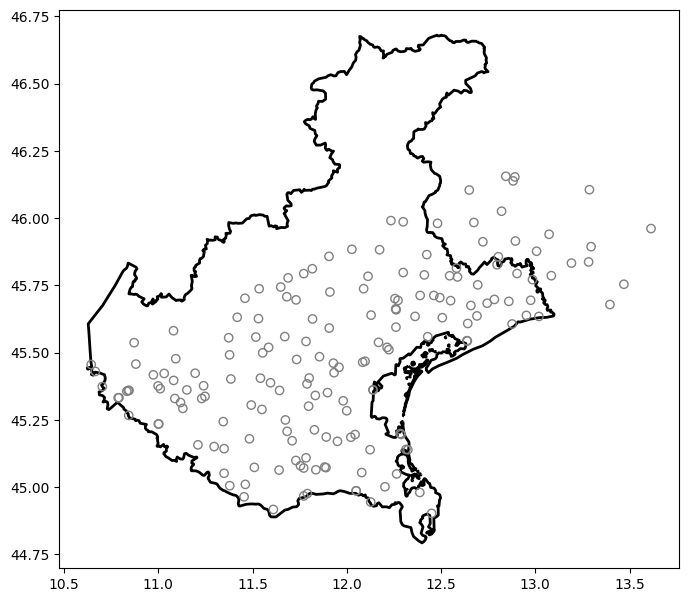

In [43]:
ax = veneto.plot(figsize=(8, 8), facecolor="none", edgecolor='black', lw=2)
points_gdf.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [33]:
resulting_points = gpd.sjoin(points_gdf, veneto, how="inner", op="within")

C:\Users\dimit\AppData\Roaming\Python\Python39\site-packages\IPython\core\interactiveshell.py:3448: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):


<Axes: >

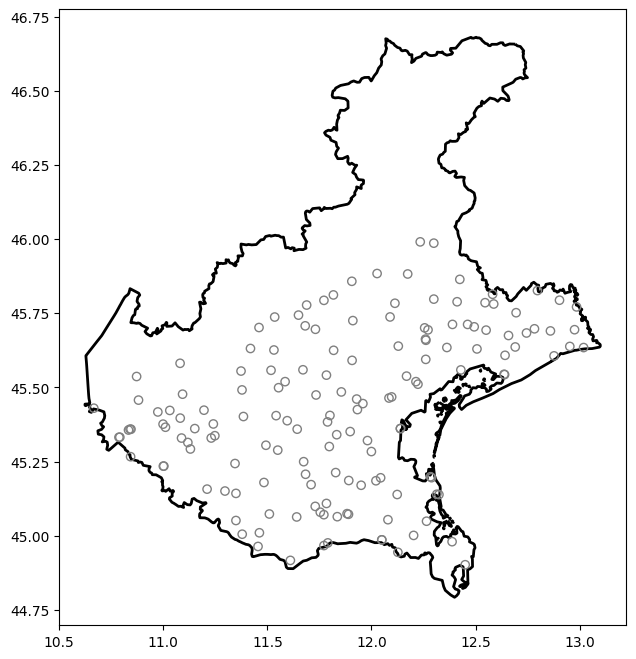

In [44]:
ax = veneto.plot(figsize=(8, 8), facecolor="none", edgecolor='black', lw=2)
resulting_points.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [38]:
resulting_points.reset_index(drop = True, inplace = True)

In [39]:
resulting_points_file = resulting_points[['x','y']]

In [40]:
resulting_points_file

,x,y
0,12.877089,45.606292
1,12.213579,45.519400
2,11.670841,45.559359
3,11.117869,45.314329
4,12.550696,45.693042
...,...,...
150,10.832730,45.356300
151,12.049587,44.986146
152,12.139038,45.361250
153,11.800410,45.405474


In [45]:
resulting_points_file.to_csv("random_data/veneto_stations.csv", encoding = 'utf-8', index = False)

In [27]:
el0 = europe_nuts0.loc[europe_nuts0['CNTR_CODE'] == 'EL']
el1 = europe_nuts1.loc[europe_nuts1['CNTR_CODE'] == 'EL']
el2 = europe_nuts2.loc[europe_nuts2['CNTR_CODE'] == 'EL']
el3 = europe_nuts3.loc[europe_nuts3['CNTR_CODE'] == 'EL']

In [28]:
el0.reset_index(drop=True, inplace=True)
el1.reset_index(drop=True, inplace=True)
el2.reset_index(drop=True, inplace=True)
el3.reset_index(drop=True, inplace=True)

In [32]:
el1_3 = el1.loc[el1['NUTS_ID'] == 'EL3'].copy()
el1_4 = el1.loc[el1['NUTS_ID'] == 'EL4'].copy()
el1_5 = el1.loc[el1['NUTS_ID'] == 'EL5'].copy()
el1_6 = el1.loc[el1['NUTS_ID'] == 'EL6'].copy()

In [33]:
el1_3.to_file('../data_snipets/EL3.shp', encoding = enc)
el1_4.to_file('../data_snipets/EL4.shp', encoding = enc)
el1_5.to_file('../data_snipets/EL5.shp', encoding = enc)
el1_6.to_file('../data_snipets/EL6.shp', encoding = enc)

In [20]:
el2

,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,geometry,CNTR_NAME
0,EL62,EL,Ionia Nisia,Ιόνια Νησιά,"MULTIPOLYGON (((21.11222 38.31611, 21.11426 38...",Greece
1,EL63,EL,Dytiki Elláda,Δυτική Ελλάδα,"MULTIPOLYGON (((22.37297 38.14222, 22.37737 38...",Greece
2,EL41,EL,Voreio Aigaio,Βόρειο Αιγαίο,"MULTIPOLYGON (((26.95446 37.75858, 26.96711 37...",Greece
3,EL42,EL,Notio Aigaio,Νότιο Αιγαίο,"MULTIPOLYGON (((29.63524 36.11068, 29.63181 36...",Greece
4,EL51,EL,"Anatoliki Makedonia, Thraki","Aνατολική Μακεδονία, Θράκη","MULTIPOLYGON (((26.35788 41.71110, 26.36917 41...",Greece
5,EL30,EL,Attiki,Aττική,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38...",Greece
6,EL61,EL,Thessalia,Θεσσαλία,"MULTIPOLYGON (((24.32680 39.33398, 24.32475 39...",Greece
7,EL65,EL,Peloponnisos,Πελοπόννησος,"MULTIPOLYGON (((23.11753 38.06065, 23.11906 38...",Greece
8,EL43,EL,Kriti,Κρήτη,"MULTIPOLYGON (((26.35266 35.26980, 26.34043 35...",Greece
9,EL52,EL,Kentriki Makedonia,Κεντρική Μακεδονία,"MULTIPOLYGON (((23.62422 41.37573, 23.62617 41...",Greece


In [21]:
el0.to_file('Greece/data/EL_NUTS0.shp', encoding = enc)
el1.to_file('Greece/data/EL_NUTS1.shp', encoding = enc)
el2.to_file('Greece/data/EL_NUTS2.shp', encoding = enc)
el3.to_file('Greece/data/EL_NUTS3.shp', encoding = enc)

In [22]:
el0.rename(columns={"NUTS_ID": "NUTS0_ID", "NAME_LATN": "NUTS0_LATN", "NUTS_NAME": "NUTS0_NAME"}, inplace=True)
el1.rename(columns={"NUTS_ID": "NUTS1_ID", "NAME_LATN": "NUTS1_LATN", "NUTS_NAME": "NUTS1_NAME"}, inplace=True)
el2.rename(columns={"NUTS_ID": "NUTS2_ID", "NAME_LATN": "NUTS2_LATN", "NUTS_NAME": "NUTS2_NAME"}, inplace=True)
el3.rename(columns={"NUTS_ID": "NUTS3_ID", "NAME_LATN": "NUTS3_LATN", "NUTS_NAME": "NUTS3_NAME"}, inplace=True)

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\frame.py:5039: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().rename(


In [23]:
el32 = el3.sjoin(el2, predicate="within", how = "left")

In [24]:
el32.drop(columns = ['index_right'], inplace = True)

In [25]:
el21 = el32.sjoin(el1, predicate="within", how = "left")

In [26]:
el21.drop(columns = ['index_right'], inplace = True)

<AxesSubplot:>

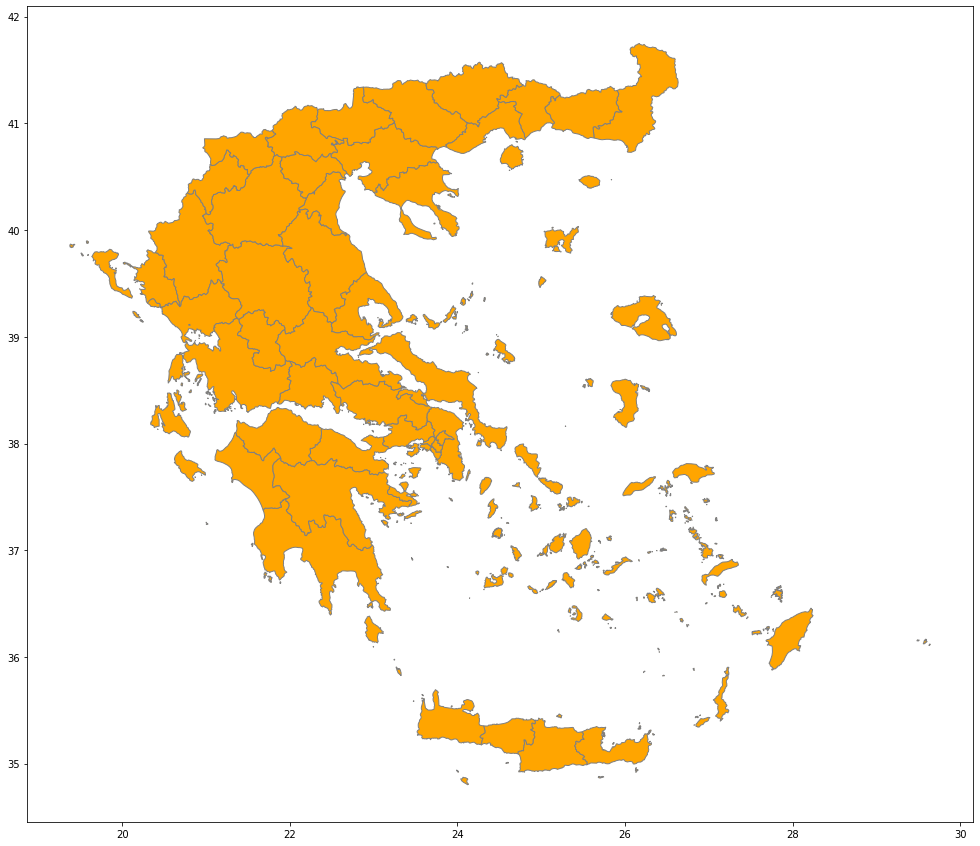

In [27]:
el21.plot(facecolor="none", edgecolor='grey', figsize=(20, 15), color='orange')

In [28]:
el21.drop(columns = ['CNTR_CODE_left', 'CNTR_NAME_left', 'CNTR_CODE_right', 'CNTR_NAME_right'], inplace = True)

In [29]:
el21.head(3)

,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry,NUTS2_ID,NUTS2_LATN,NUTS2_NAME,NUTS1_ID,CNTR_CODE,NUTS1_LATN,NUTS1_NAME,CNTR_NAME
0,EL431,Irakleio,Ηράκλειο,2.0,2,1,"MULTIPOLYGON (((25.49070 35.29833, 25.49187 35...",EL43,Kriti,Κρήτη,EL4,EL,"Nisia Aigaiou, Kriti","Νησιά Αιγαίου, Κρήτη",Greece
1,EL542,Thesprotia,Θεσπρωτία,3.0,3,1,"MULTIPOLYGON (((20.39131 39.78848, 20.40219 39...",EL54,Ipeiros,Ήπειρος,EL5,EL,Voreia Elláda,Βόρεια Ελλάδα,Greece
2,EL543,Ioannina,Ιωάννινα,3.0,2,3,"POLYGON ((21.00401 40.15407, 20.97867 40.14482...",EL54,Ipeiros,Ήπειρος,EL5,EL,Voreia Elláda,Βόρεια Ελλάδα,Greece


In [30]:
print(len(el21.columns))

15


In [31]:
el21.columns

Index(['NUTS3_ID', 'NUTS3_LATN', 'NUTS3_NAME', 'MOUNT_TYPE', 'URBN_TYPE',
       'COAST_TYPE', 'geometry', 'NUTS2_ID', 'NUTS2_LATN', 'NUTS2_NAME',
       'NUTS1_ID', 'CNTR_CODE', 'NUTS1_LATN', 'NUTS1_NAME', 'CNTR_NAME'],
      dtype='object')

In [32]:
rearranged_cols = ['CNTR_CODE', 'CNTR_NAME', 'NUTS1_ID', 'NUTS1_LATN', 'NUTS1_NAME', 'NUTS2_ID', 'NUTS2_LATN', 'NUTS2_NAME',
'NUTS3_ID', 'NUTS3_LATN', 'NUTS3_NAME', 'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE', 'geometry']

In [33]:
print(len(rearranged_cols))

15


In [34]:
el21 = el21[rearranged_cols]

In [35]:
el21.sort_values(["NUTS1_ID", "NUTS2_ID", "NUTS3_ID"], axis = 0, ascending = True, inplace = True,)

In [36]:
el21.head(5)

,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
8,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL301,Voreios Tomeas Athinon,Βόρειος Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.80300 37.98545..."
9,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL302,Dytikos Tomeas Athinon,Δυτικός Τομέας Αθηνών,4.0,1,1,"MULTIPOLYGON (((23.72005 38.06296, 23.72884 38..."
41,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL303,Kentrikos Tomeas Athinon,Κεντρικός Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.82185 37.97195..."
23,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL304,Notios Tomeas Athinon,Νότιος Τομέας Αθηνών,4.0,1,1,"POLYGON ((23.80679 37.91784, 23.80240 37.91205..."
14,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL305,Anatoliki Attiki,Ανατολική Αττική,2.0,1,1,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."


In [37]:
el21.to_file('Greece/data/EL_Whole.shp', encoding = enc)